# 02 — Feature Engineering & Exploration
This notebook visualizes the features produced by the Gold pipeline, validates their distributions, and confirms the encoding pipeline works correctly.

> **Modules Used**: `src.data_loader`, `src.features`

In [1]:
import sys
sys.path.insert(0, '..')

from src.data_loader import load_gold_table, train_test_split_by_stay
from src.features import prepare_features, get_feature_columns, NUMERIC_FEATURES
import matplotlib.pyplot as plt
import pandas as pd

df = load_gold_table()
train_df, test_df = train_test_split_by_stay(df)

Loaded 2,304,561 hourly samples across 72,082 stays.
Train: 1,842,484 samples (57,665 stays)
Test:  462,077 samples (14,417 stays)


## 2.1 Feature Matrix Preparation

In [2]:
X_train, y_train, _ = prepare_features(train_df, scale=False)

print(f"Feature matrix shape: {X_train.shape}")
print(f"Target vector shape:  {y_train.shape}")
print(f"\nFeature columns:")
for i, col in enumerate(get_feature_columns(), 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (1842484, 18)
Target vector shape:  (1842484,)

Feature columns:
   1. hr_index
   2. creatinine
   3. bun
   4. heart_rate
   5. map
   6. uo_hourly
   7. uo_ml_kg_hr
   8. age
   9. admission_weight
  10. hours_since_last_cr
  11. hours_since_last_bun
  12. hours_since_last_hr
  13. hours_since_last_map
  14. history_ckd
  15. history_diabetes
  16. history_chf
  17. history_sepsis
  18. is_male


## 2.2 Feature Distributions

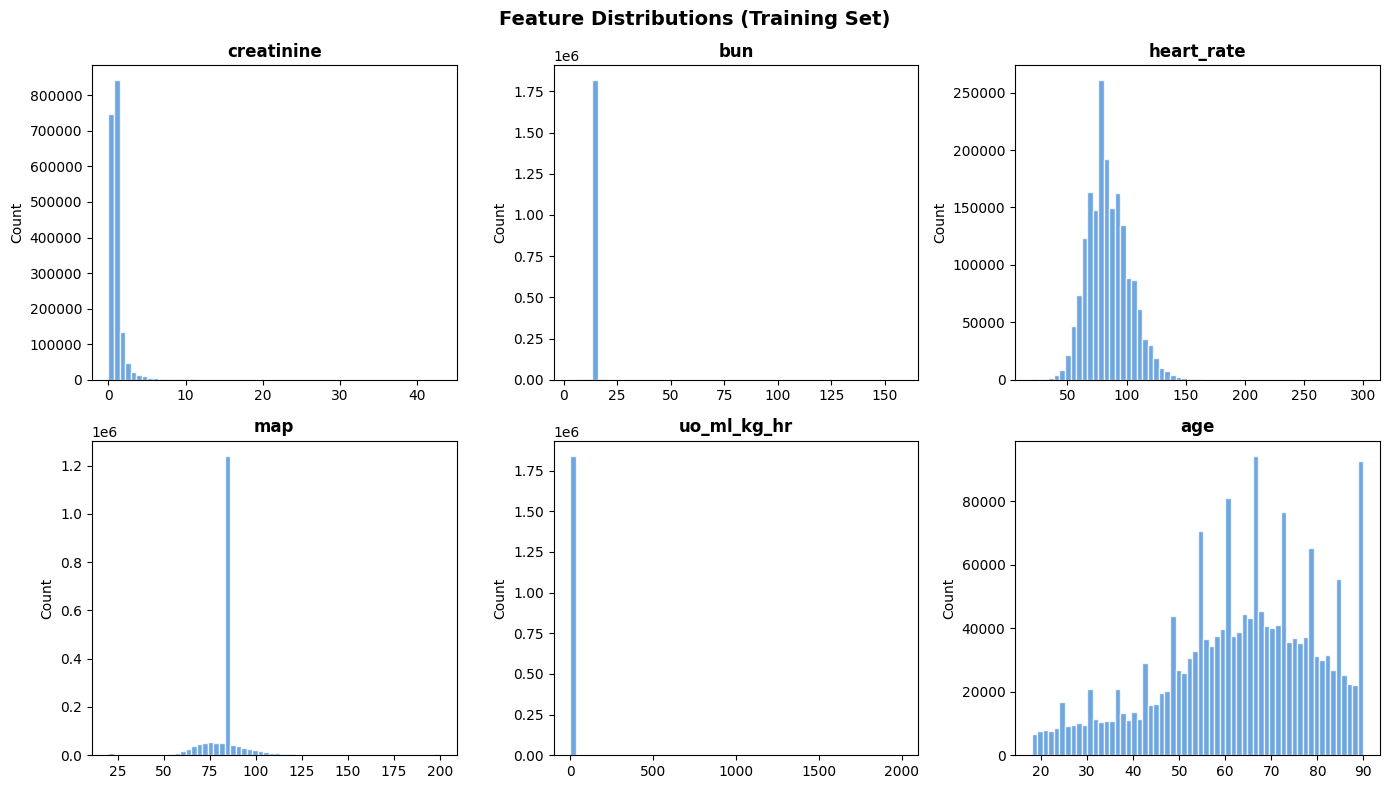

In [3]:
key_features = ['creatinine', 'bun', 'heart_rate', 'map', 'uo_ml_kg_hr', 'age']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), key_features):
    ax.hist(X_train[col].dropna(), bins=60, color='#4A90D9', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Feature Distributions (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Staleness Feature Patterns

In [4]:
staleness_cols = ['hours_since_last_cr', 'hours_since_last_bun', 'hours_since_last_hr', 'hours_since_last_map']

display(X_train[staleness_cols].describe().round(2))

,hours_since_last_cr,hours_since_last_bun,hours_since_last_hr,hours_since_last_map
count,1842484.00,1842484.00,1842484.00,1842484.00
mean,14.26,47.82,0.88,20.07
std,16.03,5.84,4.94,23.27
min,0.00,0.00,0.00,0.00
25%,3.00,48.00,0.00,1.00
50%,8.00,48.00,0.00,24.00
75%,17.00,48.00,0.00,24.00
max,229.00,331.00,238.00,576.00


## 2.4 Missing Value Check

In [5]:
null_counts = X_train.isnull().sum()
if null_counts.sum() == 0:
    print('No missing values in the feature matrix after prepare_features().')
else:
    print('Columns with missing values:')
    display(null_counts[null_counts > 0])

No missing values in the feature matrix after prepare_features().


## 2.5 Correlation Matrix

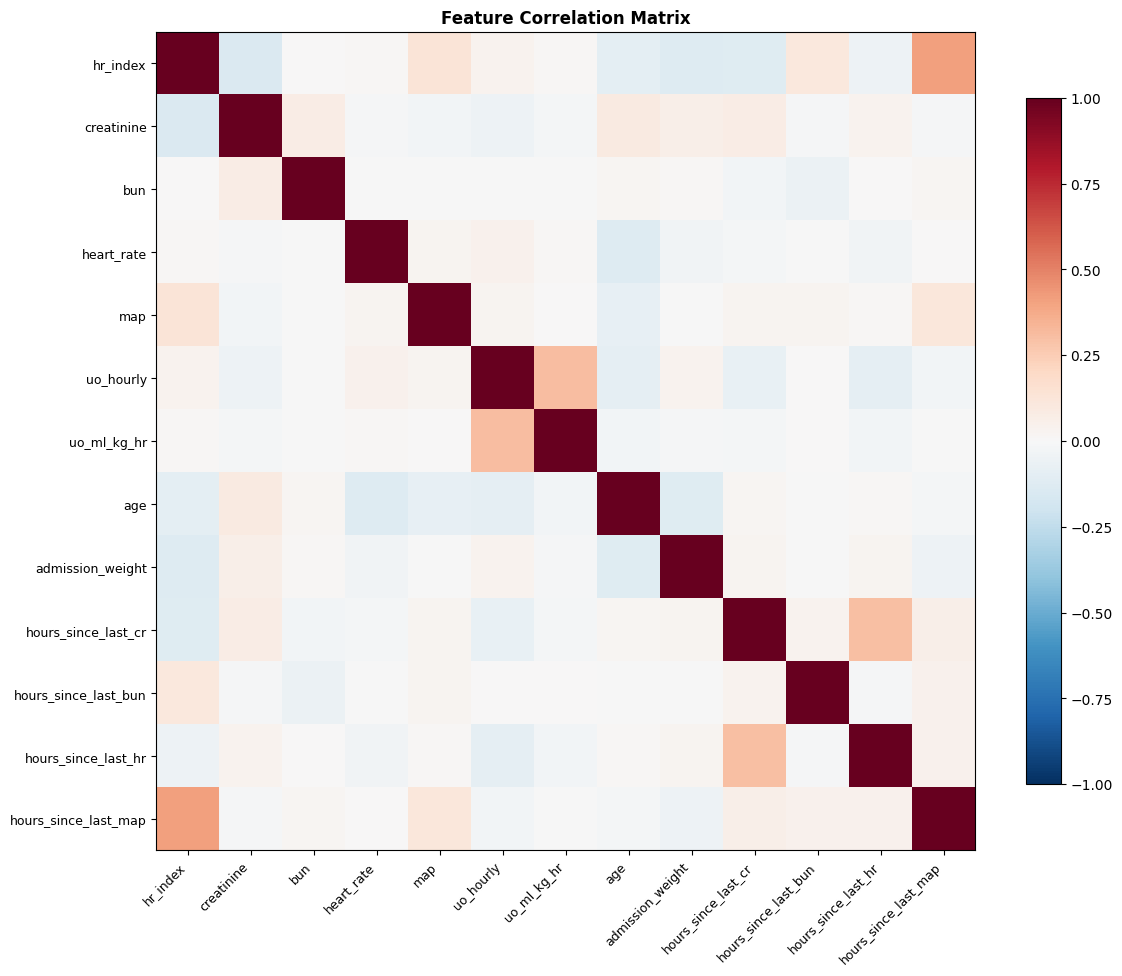

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = X_train[NUMERIC_FEATURES].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(NUMERIC_FEATURES)))
ax.set_yticks(range(len(NUMERIC_FEATURES)))
ax.set_xticklabels(NUMERIC_FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(NUMERIC_FEATURES, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()